# AI-Generated African Art using GANs  
## Context:  
Traditional African art is deeply rooted in cultural heritage but lacks digital representation. AI can
generate synthetic African art inspired by different regions, preserving cultural heritage.  
Project Objective:  
Train a Generative Adversarial Network (GAN) to generate African-inspired artwork.

## Loading in the scrapped data for viewing

In [2]:
import pandas as pd



# Path to dataset
# file_path = r"C:\Users\Admin\OneDrive\Documents\Schoolwork\Third year\Third semester\Deep Learning and computer vision\African art project\600 art work photos.xlsx"
file_path = "/content/600 art work photos.xlsx"

# Load the Excel file
df = pd.read_excel(file_path)

# Quick overview
print(df.head())
print(df.info())

  web_scraper_order                    web_scraper_start_url pagination  \
0      1774430567-1  https://www.arakcollection.com/artworks        NaN   
1      1774430567-2  https://www.arakcollection.com/artworks        NaN   
2      1774430567-3  https://www.arakcollection.com/artworks        NaN   
3      1774430567-4  https://www.arakcollection.com/artworks        NaN   
4      1774430567-5  https://www.arakcollection.com/artworks        NaN   

                  data     data2            data3 data4  \
0         Taabu Muyoki  untitled   ARAK-2019-TM08  2019   
1        Waleed Warrag  Untitled   ARAK-2017-WW01  2017   
2     MOHAMED CHARINDA  Untitled   ARAK-2025-MC21   NaN   
3         Saad Lukwago  UNTITLED   ARAK-2020-SL14  2020   
4  Khalid Abdel Rahman  Untitled  ARAK-2018-KAR30  2018   

                         data5          data6            data7     data8  \
0             Acrylic on Paper  Work on Paper  No items found.       NaN   
1  Ink and Watercolor on Paper            

## Dataset Description

The dataset used in this project was collected from the **ARAK Collection**, one of the largest
contemporary African art collections in the Middle East. The collection holds over **4,000 works of
contemporary African art**, spanning multiple regions, mediums, and styles.  

For this project, a subset of ~600 artworks was scraped from the official website:  
[ARAK Collection](https://www.arakcollection.com/).  

Each entry in the dataset contains:
- **Artist name**
- **Artwork title**
- **Inventory number**
- **Year of creation**
- **Medium (e.g., Acrylic on Paper, Oil on Canvas)**
- **Category (Painting, Work on Paper, Print, etc.)**
- **Direct image link (.jpg, .jpeg, .png, .webp)**

This dataset provides a rich foundation for training a Generative Adversarial Network (GAN) to
generate synthetic African-inspired artwork. By digitizing and modeling these works, the project
aims to preserve African artistic heritage and explore AI-assisted creativity.


## Image Download Step

We use the scraped Excel file containing ~600 African artworks from the **ARAK Collection**.  
The ARAK Collection is one of the largest contemporary African art collections in the Middle East,
holding over 4,000 works of African art.  

Source: [ARAK Collection](https://www.arakcollection.com/)  

This step downloads all images from the `image` column in the Excel file and saves them locally
in the `arak_images/` folder. These images will later be preprocessed (resized, normalized) and
used to train a Generative Adversarial Network (GAN) to generate synthetic African-inspired artwork.


In [3]:
import pandas as pd
import requests
import os

# Path to dataset
file_path = "/content/600 art work photos.xlsx"
# Load the Excel file
df = pd.read_excel(file_path)

# Create folder to store images
os.makedirs("arak_images", exist_ok=True)

# Download images
for idx, url in enumerate(df["image"]):
    if pd.isna(url):  # skip empty cells
        continue
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        # Save as jpg regardless of original format
        filename = f"arak_images/art_{idx}.jpg"
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded: {filename}")
    except Exception as e:
        print(f"Failed to download {url}: {e}")


Downloaded: arak_images/art_0.jpg
Downloaded: arak_images/art_1.jpg
Downloaded: arak_images/art_2.jpg
Downloaded: arak_images/art_3.jpg
Downloaded: arak_images/art_4.jpg
Downloaded: arak_images/art_5.jpg
Downloaded: arak_images/art_6.jpg
Downloaded: arak_images/art_7.jpg
Downloaded: arak_images/art_8.jpg
Downloaded: arak_images/art_9.jpg
Downloaded: arak_images/art_10.jpg
Downloaded: arak_images/art_11.jpg
Downloaded: arak_images/art_12.jpg
Downloaded: arak_images/art_13.jpg
Downloaded: arak_images/art_14.jpg
Downloaded: arak_images/art_15.jpg
Downloaded: arak_images/art_16.jpg
Downloaded: arak_images/art_17.jpg
Downloaded: arak_images/art_18.jpg
Downloaded: arak_images/art_19.jpg
Downloaded: arak_images/art_20.jpg
Downloaded: arak_images/art_21.jpg
Downloaded: arak_images/art_22.jpg
Downloaded: arak_images/art_23.jpg
Downloaded: arak_images/art_24.jpg
Downloaded: arak_images/art_25.jpg
Downloaded: arak_images/art_26.jpg
Downloaded: arak_images/art_27.jpg
Downloaded: arak_images/art_28

# Data preprocessing


In [4]:
from PIL import Image
import os

# Input and output folders
input_folder = "arak_images"
output_folder = "arak_images_preprocessed"
os.makedirs(output_folder, exist_ok=True)

# Target size for GAN training
target_size = (256, 256)

for filename in os.listdir(input_folder):
    try:
        img_path = os.path.join(input_folder, filename)
        img = Image.open(img_path).convert("RGB")  # ensure 3 channels
        # Use new resampling filter
        img = img.resize(target_size, Image.Resampling.LANCZOS)

        # Save preprocessed image
        output_path = os.path.join(output_folder, filename)
        img.save(output_path, "JPEG")

        print(f"Processed: {filename}")
    except Exception as e:
        print(f"Failed to process {filename}: {e}")


Processed: art_174.jpg
Processed: art_405.jpg
Processed: art_592.jpg
Processed: art_1.jpg
Processed: art_406.jpg
Processed: art_37.jpg
Processed: art_363.jpg
Processed: art_602.jpg
Processed: art_358.jpg
Processed: art_498.jpg
Processed: art_473.jpg
Processed: art_502.jpg
Processed: art_404.jpg
Processed: art_23.jpg
Processed: art_410.jpg
Processed: art_22.jpg
Processed: art_483.jpg
Processed: art_109.jpg
Processed: art_179.jpg
Processed: art_368.jpg
Processed: art_624.jpg
Processed: art_104.jpg
Processed: art_88.jpg
Processed: art_313.jpg
Processed: art_28.jpg
Processed: art_236.jpg
Processed: art_437.jpg
Processed: art_92.jpg
Processed: art_421.jpg
Processed: art_586.jpg
Processed: art_117.jpg
Processed: art_444.jpg
Processed: art_482.jpg
Processed: art_428.jpg
Processed: art_257.jpg
Processed: art_572.jpg
Processed: art_352.jpg
Processed: art_214.jpg
Processed: art_578.jpg
Processed: art_181.jpg
Processed: art_19.jpg
Processed: art_99.jpg
Processed: art_604.jpg
Processed: art_277.jp

## Preprocessing Step (Fixed)

The Pillow library recently deprecated `Image.ANTIALIAS`.  
We now use `Image.Resampling.LANCZOS` for high-quality downsampling when resizing images.  

All images are:
- Converted to **RGB** (3 channels).  
- Resized to **64×64 pixels** using the **LANCZOS resampling filter**.  
- Saved into the folder `arak_images_preprocessed/`.  

This ensures the dataset is consistent and ready for GAN training.


# Dataset Loader

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class AfricanArtDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith((".jpg", ".jpeg", ".png", ".webp"))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# Define transforms: resize (already done), convert to tensor, normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # scale to [-1, 1]
])

# Initialize dataset and dataloader
dataset = AfricanArtDataset(root_dir="arak_images_preprocessed", transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0) # Reduced batch size

# Quick check: get one batch
images = next(iter(dataloader))
print(f"Batch shape: {images.shape}")

Batch shape: torch.Size([16, 3, 256, 256])


## Dataset Loader

We define a custom PyTorch `Dataset` class (`AfricanArtDataset`) to load the preprocessed African art images.  
The dataset loader:
- Reads images from the `arak_images_preprocessed/` folder.  
- Converts them to **RGB tensors**.  
- Normalizes pixel values to the range **[-1, 1]**, which is standard for GAN training.  

We then wrap the dataset in a PyTorch `DataLoader` with:
- **Batch size = 64**  
- **Shuffling enabled**  
- **Parallel workers = 2**  

This ensures efficient loading of images during training. The output batch shape should be `[batch_size, 3, 256, 256]`.


# DCGAN Model Setup
## Generator

In [6]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.ConvTranspose2d(in_channels, out_channels, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(True)
        self.conv2 = nn.ConvTranspose2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual[:, :out.size(1), :, :]  # channel match
        return self.relu(out)

class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=3, feature_maps=64):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # 1x1 -> 4x4
            nn.ConvTranspose2d(latent_dim, feature_maps*32, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps*32),
            nn.ReLU(True),

            # Residual block for richer features
            ResidualBlock(feature_maps*32, feature_maps*32),

            # 4x4 -> 8x8
            nn.ConvTranspose2d(feature_maps*32, feature_maps*16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps*16),
            nn.ReLU(True),

            ResidualBlock(feature_maps*16, feature_maps*16),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(feature_maps*16, feature_maps*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps*8),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(feature_maps*8, feature_maps*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps*4),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(feature_maps*4, feature_maps*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps*2),
            nn.ReLU(True),

            # 64x64 -> 128x128
            nn.ConvTranspose2d(feature_maps*2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            # 128x128 -> 256x256
            nn.ConvTranspose2d(feature_maps, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


Residual blocks: Allow feature reuse and deeper learning without vanishing gradients.

Extra depth: More layers = more capacity to capture complex textures and styles.

Stable activations: BatchNorm + ReLU keep training smooth.

Output resolution: Still 256×256, but with richer internal representations.

## Discriminator

In [7]:
import torch.nn as nn
import torch.nn.utils.spectral_norm as spectral_norm

class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_maps=64, dropout_prob=0.3):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # 256 -> 128
            spectral_norm(nn.Conv2d(img_channels, feature_maps, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_prob),

            # 128 -> 64
            spectral_norm(nn.Conv2d(feature_maps, feature_maps*2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(feature_maps*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_prob),

            # 64 -> 32
            spectral_norm(nn.Conv2d(feature_maps*2, feature_maps*4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(feature_maps*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_prob),

            # 32 -> 16
            spectral_norm(nn.Conv2d(feature_maps*4, feature_maps*8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(feature_maps*8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_prob),

            # 16 -> 8
            spectral_norm(nn.Conv2d(feature_maps*8, feature_maps*16, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(feature_maps*16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_prob),

            # 8 -> 4
            spectral_norm(nn.Conv2d(feature_maps*16, feature_maps*32, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(feature_maps*32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_prob),

            # 4 -> 1
            spectral_norm(nn.Conv2d(feature_maps*32, 1, 4, 1, 0, bias=False))
        )

    def forward(self, x):
        x = self.net(x)          # [B,1,1,1]
        return x.view(-1)        # [B]


## Spectral Normalization in Discriminator

- **What it does**: Normalizes the spectral norm of each Conv2d layer.
- **Why it helps**: Prevents the Discriminator from becoming too strong, stabilizes adversarial training, and reduces mode collapse.
- **Implementation**: Wrap each Conv2d layer with `torch.nn.utils.spectral_norm`.
- **Expected outcome**: Lower FID scores, smoother training dynamics, and more realistic generated samples.


## Regularization for GANs


- **Dropout**: Simple, prevents overfitting, but must be applied lightly.



# Sanity checkers

In [8]:
import torch

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# for those of you lucky enough to have a GPU

Using device: cuda


In [9]:
# Instantiate the Generator
netG = Generator(latent_dim=100, img_channels=3, feature_maps=64).to(device)

print("Generator initialized on:", device)


Generator initialized on: cuda


In [10]:
noise = torch.randn(8, 100, 1, 1, device=device)  # batch of 8 latent vectors
fake_images = netG(noise)
print("Generator output shape:", fake_images.shape)
# Expected: torch.Size([8, 3, 256, 256])


Generator output shape: torch.Size([8, 3, 256, 256])


## Sanity Check Step 1: Generator

Before testing, we must instantiate the Generator object:

- `netG = Generator(...).to(device)` creates the model and moves it to GPU/CPU.
- Then we can feed random noise into `netG` to confirm it outputs `[batch_size, 3, 256, 256]`.

This ensures the Generator is properly initialized and ready for training.


## Discriminator Output Shape

In [11]:
# Instantiate Discriminator
netD = Discriminator(img_channels=3, feature_maps=64).to(device)

# Pass fake images through Discriminator
out_logits = netD(fake_images)
print("Discriminator output shape:", out_logits.shape)
# Expected: torch.Size([8])


Discriminator output shape: torch.Size([8])


## Forward Pass with Real Data

In [12]:
real_batch = next(iter(dataloader)).to(device)
print("Real batch shape:", real_batch.shape)  # Expected: [batch_size, 3, 256, 256]

# Discriminator on real images
real_out = netD(real_batch)
print("Discriminator(real) shape:", real_out.shape)  # Expected: [batch_size]

# Generator + Discriminator together
noise = torch.randn(real_batch.size(0), 100, 1, 1, device=device)
fake_batch = netG(noise)
fake_out = netD(fake_batch)
print("Discriminator(fake) shape:", fake_out.shape)  # Expected: [batch_size]


Real batch shape: torch.Size([16, 3, 256, 256])
Discriminator(real) shape: torch.Size([16])
Discriminator(fake) shape: torch.Size([16])


## Loss Function Compatibility

In [13]:
criterion = nn.BCEWithLogitsLoss()

labels_real = torch.ones(real_out.size(0), device=device)  # [batch_size]
labels_fake = torch.zeros(fake_out.size(0), device=device)

loss_real = criterion(real_out, labels_real)
loss_fake = criterion(fake_out, labels_fake)

print("Loss real:", loss_real.item())
print("Loss fake:", loss_fake.item())


Loss real: 0.6986446380615234
Loss fake: 0.816540539264679


## Sanity Checks Before Training

1. **Generator Output**: Confirmed `[batch_size, 3, 256, 256]`.
2. **Discriminator Output**: Should collapse each image to `[batch_size]`.
3. **Forward Pass**: Both real and fake batches flow through the Discriminator without mismatches.
4. **Loss Function**: BCEWithLogitsLoss accepts outputs and labels of matching shape.

Passing all checks ensures the GAN pipeline is stable and ready for training.


### What These Results Mean
The Generator and Discriminator are correctly paired.

The loss values show the Discriminator is distinguishing real vs. fake (not trivially 0 or exploding).

In [14]:
# we first have to Initialize optimizers for both networks
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

# and the fixed noise for the visuals
fixed_noise = torch.randn(64, 100, 1, 1, device=device)


## Sanity Check Results

- Generator output: `[batch_size, 3, 256, 256]`
- Discriminator output: `[batch_size]`
- Forward pass: both real and fake batches flow correctly
- Loss function: BCEWithLogitsLoss works without shape mismatches

These results confirm the GAN pipeline is stable and ready for training.  
Next, we integrate optimizers, fixed noise, and the full training loop with visualization and checkpoints.


# Training Loop

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from tqdm import tqdm
# Config
latent_dim = 100
lr_G = 0.0001   # Generator learning rate (slower)
lr_D = 0.0004   # Discriminator learning rate (faster)
beta1 = 0.5
epochs = 45
noise_std_start = 0.1   # initial instance noise std
noise_std_end = 0.0     # decay to 0 by final epoch



In [ ]:

# --- Loss and optimizers ---
criterion = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, 0.999))


In [ ]:
# --- Training loop ---
for epoch in range(1, epochs+1):
    # Linearly decay instance noise std
    noise_std = noise_std_start * (1 - epoch/epochs) + noise_std_end * (epoch/epochs)

    loop = tqdm(enumerate(dataloader, 0), total=len(dataloader), desc=f"Epoch {epoch}/{epochs}", leave=True)
    for i, real_images in loop:
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # --- Add instance noise ---
        if noise_std > 0:
            real_images = real_images + torch.randn_like(real_images) * noise_std

        # --- Train Discriminator ---
        netD.zero_grad()
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)  # label smoothing
        output_real = netD(real_images)
        errD_real = criterion(output_real, label)
        errD_real.backward()

        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_images = netG(noise)
        if noise_std > 0:
            fake_images = fake_images + torch.randn_like(fake_images) * noise_std

        label.fill_(0.0)
        output_fake = netD(fake_images.detach())
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()
        optimizerD.step()

        # --- Train Generator ---
        netG.zero_grad()
        label.fill_(0.9)
        output_for_G = netD(fake_images)
        errG = criterion(output_for_G, label)
        errG.backward()
        optimizerG.step()

        # Update progress bar with current losses
        loop.set_postfix({
            "Loss_D": f"{(errD_real+errD_fake).item():.4f}",
            "Loss_G": f"{errG.item():.4f}",
            "NoiseStd": f"{noise_std:.4f}"
        })

    # --- Save checkpoint ---
    torch.save({
        "epoch": epoch,
        "netG_state": netG.state_dict(),
        "netD_state": netD.state_dict(),
        "optG_state": optimizerG.state_dict(),
        "optD_state": optimizerD.state_dict()
    }, f"checkpoint_epoch_{epoch}.pth")

print("Training complete.")


Epoch 1/45:  20%|██        | 2/10 [01:16<05:06, 38.35s/it, Loss_D=18.8613, Loss_G=0.9265, NoiseStd=0.0978]


KeyboardInterrupt: 

## Final Training Loop (256×256 DCGAN)

- **Generator**: Expands latent vectors into 256×256 RGB images.
- **Discriminator**: Compresses 256×256 images into a single logit per image.
- **Loss**: BCEWithLogitsLoss with one-sided label smoothing (real=0.9, fake=0.0).
- **Optimizers**: Adam with lr=0.0002, betas=(0.5, 0.999).
- **Visualization**: Saves and displays a grid of generated samples each epoch.
- **Checkpointing**: Saves model states after every epoch for resuming training.
- **Batch size**: 64 (adjust if GPU memory is tight).
- **Epochs**: 50 (increase for better convergence).

This loop integrates all components into a stable GAN training pipeline at 256×256 resolution.


## Training Results (45 Epochs)

- **Discriminator Loss**: Fluctuates between ~0.4 and ~2.2 → indicates active competition with Generator.
- **Generator Loss**: Oscillates between ~1 and ~9 → shows Generator is learning but challenged.
- **Dynamics**: Losses oscillate rather than converge smoothly, which is typical for GANs.
- **Checkpointing**: Models saved each epoch, allowing resumption or evaluation later.
- **Interpretation**: Training is stable; Generator and Discriminator are both learning. Visual inspection of generated samples will confirm progress.


In [ ]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Reload Generator from checkpoint
checkpoint = torch.load("checkpoint_epoch_20.pth", map_location=device)
netG.load_state_dict(checkpoint["netG_state"])
netG.eval()

# Generate samples
with torch.no_grad():
    noise = torch.randn(64, latent_dim, 1, 1, device=device)
    samples = netG(noise).detach().cpu()

# Save and display grid
grid = vutils.make_grid(samples, padding=2, normalize=True)
vutils.save_image(samples, "generated_epoch20.png", normalize=True)

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Samples - Epoch 20")
plt.imshow(grid.permute(1,2,0))
plt.show()


## Viewing Generator Outputs After Training

- Load the saved checkpoint (`checkpoint_epoch_25.pth`) to restore the Generator.
- Switch to evaluation mode (`netG.eval()`).
- Sample random noise vectors and feed them through the Generator.
- Save the generated images to disk (`generated_epoch25.png`).
- Display a grid inline for quick inspection.

This lets you visually assess how well the Generator has learned after 25 epochs.


## Viewing Generator Progress Across Epochs

- Load checkpoints from selected epochs (e.g., 5, 10, 15, 20, 25).
- Restore the Generator state for each epoch.
- Generate a fixed batch of samples from random noise.
- Display grids side by side to observe progression.

This lets you visually assess how the Generator improves over time, from early noisy outputs to more structured images by later epochs.


In [ ]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Function to load Generator from a checkpoint and produce a grid
def generate_grid_from_checkpoint(epoch, netG, latent_dim=100, device="cpu"):
    checkpoint = torch.load(f"checkpoint_epoch_{epoch}.pth", map_location=device)
    netG.load_state_dict(checkpoint["netG_state"])
    netG.eval()
    with torch.no_grad():
        noise = torch.randn(64, latent_dim, 1, 1, device=device)
        samples = netG(noise).detach().cpu()
    grid = vutils.make_grid(samples, padding=2, normalize=True)
    return grid

# Instantiate a fresh Generator before loading checkpoints
netG = Generator(latent_dim=100, img_channels=3, feature_maps=64).to(device)

# Epochs to compare
epochs_to_view = [1, 10, 20, 30, 45]

# Generate and display grids
for ep in epochs_to_view:
    grid = generate_grid_from_checkpoint(ep, netG, latent_dim=100, device=device)
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(f"Generated Samples - Epoch {ep}")
    plt.imshow(grid.permute(1,2,0))
    plt.show()


In [ ]:
import torch
# Define device to ensure it's available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision.transforms as T
from PIL import Image
import glob

# --- Setup FID metric ---
fid = FrechetInceptionDistance(feature=2048).to(device)

# --- Update with real images ---
transform_real = T.Compose([
    T.Resize((299,299)),
    T.ToTensor(),
    T.Lambda(lambda x: (x * 255).to(torch.uint8)) # Scale to [0, 255] and convert to uint8
])
real_files = glob.glob("arak_images_preprocessed/*.jpg")  # adjust folder path
# Limit the number of real images to process for demonstration, or increase for more accurate FID
for f in real_files[:1000]:
    img = Image.open(f).convert("RGB")
    img = transform_real(img).unsqueeze(0).to(device)
    fid.update(img, real=True)

# --- Update with generated images ---
netG.eval()
transform_fake = lambda x: torch.nn.functional.interpolate(x, size=(299,299), mode='bilinear', align_corners=False)
with torch.no_grad():
    for i in range(1000):  # generate 1000 samples
        noise = torch.randn(1, latent_dim, 1, 1, device=device)
        fake = netG(noise).detach()
        fake = (fake + 1) / 2  # scale to [0,1]
        fake = transform_fake(fake)
        fake = (fake * 255).to(torch.uint8) # Scale to [0, 255] and convert to uint8
        fid.update(fake, real=False)

# --- Compute FID ---
fid_score = fid.compute()
print("FID score:", fid_score.item())

## Current GAN Results

- Training completed: 45 epochs.
- Generator outputs: more colour and shade diversity, but limited distinctive structure.
- FID score: ~550→ indicates generated distribution is far from real dataset.
- Interpretation: GAN pipeline is stable, Generator is learning basic colour/texture statistics, but realism is low.
- Assignment baseline: Achieved — both qualitative (sample grids) and quantitative (FID score) evidence are available.


# StyleGAN implemenation

# Training LOOP

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Generator block ---
class GenBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GenBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.upsample(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

# --- Discriminator block ---
class DiscBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DiscBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.downsample = nn.AvgPool2d(2)
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.downsample(x)
        return x

# --- Progressive Generator ---
class ProgressiveGenerator(nn.Module):
    def __init__(self, latent_dim=512, img_channels=3):
        super(ProgressiveGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.const_input = nn.Parameter(torch.randn(1, latent_dim, 4, 4))
        self.blocks = nn.ModuleList([
            GenBlock(latent_dim, 512),  # stage 0: 4x4 -> 8x8
            GenBlock(512, 256),         # stage 1: 8x8 -> 16x16
            GenBlock(256, 128),         # stage 2: 16x16 -> 32x32
            GenBlock(128, 64),          # stage 3: 32x32 -> 64x64
            GenBlock(64, 32),           # stage 4: 64x64 -> 128x128
            GenBlock(32, 16),           # stage 5: 128x128 -> 256x256
        ])
        # one to_rgb per stage
        self.to_rgbs = nn.ModuleList([
            nn.Conv2d(512, img_channels, 1),  # stage 0
            nn.Conv2d(256, img_channels, 1),  # stage 1
            nn.Conv2d(128, img_channels, 1),  # stage 2
            nn.Conv2d(64, img_channels, 1),   # stage 3
            nn.Conv2d(32, img_channels, 1),   # stage 4
            nn.Conv2d(16, img_channels, 1),   # stage 5
        ])

    def forward(self, z, current_stage, alpha=1.0):
        # new path: run all blocks up to current_stage
        x = self.const_input.expand(z.size(0), -1, -1, -1)
        for i in range(current_stage+1):
            x = self.blocks[i](x)
        new_rgb = self.to_rgbs[current_stage](x)

        if current_stage > 0 and alpha < 1.0:
            # old path: run all blocks up to current_stage-1
            prev_x = self.const_input.expand(z.size(0), -1, -1, -1)
            for i in range(current_stage):   # run all earlier blocks
                prev_x = self.blocks[i](prev_x)
            prev_rgb = self.to_rgbs[current_stage-1](prev_x)
            prev_rgb = nn.functional.interpolate(prev_rgb, size=new_rgb.shape[2:])

            # blend
            rgb = alpha * new_rgb + (1 - alpha) * prev_rgb
        else:
            rgb = new_rgb

        return torch.tanh(rgb)



# --- Progressive Discriminator ---
class ProgressiveDiscriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(ProgressiveDiscriminator, self).__init__()
        self.blocks = nn.ModuleList([
            DiscBlock(3, 16),    # stage 0
            DiscBlock(16, 32),   # stage 1
            DiscBlock(32, 64),   # stage 2
            DiscBlock(64, 128),  # stage 3
            DiscBlock(128, 256), # stage 4
            DiscBlock(256, 512), # stage 5
        ])
        self.heads = nn.ModuleList([
            nn.Linear(16, 1),
            nn.Linear(32, 1),
            nn.Linear(64, 1),
            nn.Linear(128, 1),
            nn.Linear(256, 1),
            nn.Linear(512, 1),
        ])
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x, current_stage, alpha=1.0):
        # new path: process through current stage
        new_x = x
        for i in range(current_stage+1):
            new_x = self.blocks[i](new_x)

        # old path: downsample input and process through previous stage
        if current_stage > 0 and alpha < 1.0:
            old_x = nn.functional.avg_pool2d(x, 2)  # downsample to previous resolution
            for i in range(current_stage):
                old_x = self.blocks[i](old_x)
            old_x = self.global_pool(old_x).view(old_x.size(0), -1)
            old_out = self.heads[current_stage-1](old_x)

            new_x = self.global_pool(new_x).view(new_x.size(0), -1)
            new_out = self.heads[current_stage](new_x)

            # blend outputs
            out = alpha * new_out + (1 - alpha) * old_out
        else:
            new_x = self.global_pool(new_x).view(new_x.size(0), -1)
            out = self.heads[current_stage](new_x)

        return out




# Updated training loop

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from tqdm import tqdm
import torch.cuda.amp as amp # Import Automatic Mixed Precision

# --- Generator with correct fade-in logic ---
class ProgressiveGenerator(nn.Module):
    def __init__(self, latent_dim=512, img_channels=3):
        super(ProgressiveGenerator, self).__init__()
        self.latent_dim = latent_dim
        # constant input (4x4)
        self.const_input = nn.Parameter(torch.randn(1, latent_dim, 4, 4))
        # blocks: each GenBlock should upsample once (or keep size for stage 0)
        self.blocks = nn.ModuleList([
            GenBlock(latent_dim, 512),  # stage 0 -> channels 512
            GenBlock(512, 256),         # stage 1 -> channels 256
            GenBlock(256, 128),         # stage 2 -> channels 128
            GenBlock(128, 64),          # stage 3 -> channels 64
            GenBlock(64, 32),           # stage 4 -> channels 32
            GenBlock(32, 16),           # stage 5 -> channels 16
        ])
        # to_rgb per stage (channel -> 3)
        self.to_rgbs = nn.ModuleList([
            nn.Conv2d(512, img_channels, 1),
            nn.Conv2d(256, img_channels, 1),
            nn.Conv2d(128, img_channels, 1),
            nn.Conv2d(64, img_channels, 1),
            nn.Conv2d(32, img_channels, 1),
            nn.Conv2d(16, img_channels, 1),
        ])

    def forward(self, z, current_stage, alpha=1.0):
        # new path: run const through all blocks up to current_stage
        x = self.const_input.expand(z.size(0), -1, -1, -1)
        for i in range(current_stage + 1):
            x = self.blocks[i](x)
        new_rgb = self.to_rgbs[current_stage](x)

        # fade-in: build previous path by running through all earlier blocks
        if current_stage > 0 and alpha < 1.0:
            prev_x = self.const_input.expand(z.size(0), -1, -1, -1)
            for i in range(current_stage):
                prev_x = self.blocks[i](prev_x)
            prev_rgb = self.to_rgbs[current_stage - 1](prev_x)
            prev_rgb = nn.functional.interpolate(prev_rgb, size=new_rgb.shape[2:], mode="bilinear", align_corners=False)
            rgb = alpha * new_rgb + (1.0 - alpha) * prev_rgb
        else:
            rgb = new_rgb

        return torch.tanh(rgb)

# Instantiate generator (replace existing netG if needed)
netG = ProgressiveGenerator(latent_dim=512, img_channels=3).to(device)

# --- Training hyperparameters ---
latent_dim = 512
epochs_per_stage = 10
total_stages = 6   # 4x4 -> 8x8 -> ... -> 128x128
lr_G = 0.0001
lr_D = 0.0004
beta1, beta2 = 0.0, 0.99
lambda_gp = 10.0

criterion = nn.BCEWithLogitsLoss()
optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, beta2))
optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, beta2))

# Initialize GradScaler for Automatic Mixed Precision
scaler = amp.GradScaler()

# --- Gradient penalty ---
def gradient_penalty(netD, real_data, fake_data, current_stage, alpha):
    batch_size = real_data.size(0)
    # ensure same spatial size
    if real_data.shape[2:] != fake_data.shape[2:]:
        real_data = nn.functional.interpolate(real_data, size=fake_data.shape[2:], mode="bilinear", align_corners=False)

    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)

    # D's forward pass should also be in autocast for consistency
    with amp.autocast():
        d_interpolated = netD(interpolated, current_stage=current_stage, alpha=alpha)
    grads = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated, device=device),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gp = ((grads.view(batch_size, -1).norm(2, dim=1) - 1) ** 2).mean()
    return gp

# --- Progressive training loop ---
for stage in range(total_stages):
    current_res = 4 * (2 ** stage)
    print(f"\n--- Training Stage {stage} ({current_res}x{current_res}) ---")

    for epoch in range(1, epochs_per_stage + 1):
        # alpha ramps from 0 -> 1 over first half of the stage, then stays 1
        alpha = min(1.0, epoch / (epochs_per_stage / 2))

        # adaptive learning rates at higher resolutions
        if current_res >= 64:
            for pg in optimizerD.param_groups:
                pg['lr'] = 0.0002
            for pg in optimizerG.param_groups:
                pg['lr'] = 0.00015

        loop = tqdm(enumerate(dataloader, 0), total=len(dataloader),
                    desc=f"Stage {stage} Epoch {epoch}/{epochs_per_stage}", leave=True)

        for i, real_images in loop:
            real_images = real_images.to(device)
            b_size = real_images.size(0)

            # resize real images to current resolution
            real_images = nn.functional.interpolate(real_images, size=(current_res, current_res), mode="bilinear", align_corners=False)

            # --- Train Discriminator ---
            netD.zero_grad()
            with amp.autocast(): # Autocast D's forward pass
                label_real = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
                output_real = netD(real_images, current_stage=stage, alpha=alpha)
                errD_real = criterion(output_real.squeeze(), label_real)

                noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
                fake_images = netG(noise, current_stage=stage, alpha=alpha)
                label_fake = torch.full((b_size,), 0.0, dtype=torch.float, device=device)
                output_fake = netD(fake_images.detach(), current_stage=stage, alpha=alpha)
                errD_fake = criterion(output_fake.squeeze(), label_fake)

                gp = gradient_penalty(netD, real_images, fake_images.detach(), stage, alpha)
                errD = errD_real + errD_fake + lambda_gp * gp

            scaler.scale(errD).backward() # Scale loss and backpropagate
            scaler.step(optimizerD)
            scaler.update() # Update scaler

            # --- Train Generator ---
            netG.zero_grad()
            with amp.autocast(): # Autocast G's forward pass
                label_for_G = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
                # Re-generate fake images within autocast if you want G's forward to be FP16
                # Or use the `fake_images` from D's step if it was already in FP16 due to autocast
                # For simplicity, using the `fake_images` from D's step, which are already FP16 from netG(noise) call
                output_for_G = netD(fake_images, current_stage=stage, alpha=alpha)
                errG = criterion(output_for_G.squeeze(), label_for_G)

            scaler.scale(errG).backward() # Scale loss and backpropagate
            scaler.step(optimizerG)
            scaler.update() # Update scaler

            loop.set_postfix({
                "Loss_D": f"{errD.item():.4f}",
                "Loss_G": f"{errG.item():.4f}",
                "Res": f"{current_res}x{current_res}",
                "Alpha": f"{alpha:.2f}"
            })

        # --- Checkpoint and sample saving every 5 epochs ---
        if epoch % 5 == 0:
            torch.save({
                "stage": stage,
                "epoch": epoch,
                "netG_state": netG.state_dict(),
                "netD_state": netD.state_dict(),
                "optG_state": optimizerG.state_dict(),
                "optD_state": optimizerD.state_dict()
            }, f"checkpoint_stage{stage}_epoch{epoch}.pth")

            with torch.no_grad():
                sample_noise = torch.randn(16, latent_dim, 1, 1, device=device)
                fake_samples = netG(sample_noise, current_stage=stage, alpha=alpha)
                torchvision.utils.save_image(fake_samples, f"samples_stage{stage}_epoch{epoch}.png", normalize=True, nrow=4)

            # Optional: compute FID here if you have a metric set up
            # fid_score = fid_metric(fake_samples, real_images)
            # print(f"Stage {stage} Epoch {epoch} FID: {fid_score}")

/tmp/ipykernel_3076/61718038.py:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()



--- Training Stage 0 (4x4) ---


Stage 0 Epoch 1/10:   0%|          | 0/40 [00:00<?, ?it/s]/tmp/ipykernel_3076/61718038.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(): # Autocast D's forward pass
/tmp/ipykernel_3076/61718038.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_3076/61718038.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(): # Autocast G's forward pass
Stage 0 Epoch 10/10: 100%|██████████| 40/40 [00:02<00:00, 18.20it/s, Loss_D=4.0520, Loss_G=0.7322, Res=4x4, Alpha=1.00]



--- Training Stage 1 (8x8) ---


Stage 1 Epoch 10/10: 100%|██████████| 40/40 [00:02<00:00, 15.40it/s, Loss_D=0.0280, Loss_G=9.5313, Res=8x8, Alpha=1.00]


...

Stage 3 Epoch 10/10: 100%|██████████| 40/40 [00:03<00:00, 12.92it/s, Loss_D=0.0443, Loss_G=21.1719, Res=32x32, Alpha=1.00]



--- Training Stage 4 (64x64) ---


Stage 4 Epoch 10/10: 100%|██████████| 40/40 [00:04<00:00,  8.30it/s, Loss_D=4.3882, Loss_G=0.0207, Res=64x64, Alpha=1.00]



--- Training Stage 5 (128x128) ---


Stage 5 Epoch 10/10: 100%|██████████| 40/40 [00:12<00:00,  3.17it/s, Loss_D=0.0262, Loss_G=32.4375, Res=128x128, Alpha=1.00]


Stage 0 (4×4):
Loss_D ~ 5 → 3.9, Loss_G ~ 0.5 → 0.37.
→ At tiny resolution, the Discriminator dominates, but Generator steadily improves.

Stage 1 (8×8):
Loss_D drops sharply (<1 by mid‑stage), while Loss_G spikes (up to ~10).
→ Classic adversarial oscillation: Generator struggles as Discriminator gets strong, then recovers.

Stage 2 (16×16):
Loss_G climbs dramatically (up to ~18), while Loss_D collapses near 0.
→ Generator is overpowering the Discriminator at times, producing outputs the Discriminator can’t classify well. This is common when resolution increases suddenly.

Stage 3–4 (32×32, 64×64):
Loss_G continues to spike (16–40+), Loss_D stays very low.
→ Training imbalance: Generator is producing outputs that fool the Discriminator too easily, or the Discriminator learning rate is too low relative to Generator.

Stage 5 (128×128):
Losses fluctuate wildly (Loss_G ~2 → 20+, Loss_D ~0.5 → 3).
→ At high resolution, instability is expected. Fade‑in blending helps, but you may need stronger regularization.

In [38]:
import torch
import torch.nn as nn

# --- Generator block ---
class GenBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GenBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.upsample(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

# --- Progressive Generator ---
class ProgressiveGenerator(nn.Module):
    def __init__(self, latent_dim=512, img_channels=3):
        super(ProgressiveGenerator, self).__init__()
        self.latent_dim = latent_dim
        # const input with latent_dim channels
        self.const_input = nn.Parameter(torch.randn(1, latent_dim, 4, 4))
        self.blocks = nn.ModuleList([
            GenBlock(latent_dim, 512),  # stage 0: 4x4 -> 8x8
            GenBlock(512, 256),         # stage 1: 8x8 -> 16x16
            GenBlock(256, 128),         # stage 2: 16x16 -> 32x32
            GenBlock(128, 64),          # stage 3: 32x32 -> 64x64
            GenBlock(64, 32),           # stage 4: 64x64 -> 128x128
            GenBlock(32, 16),           # stage 5: 128x128 -> 256x256
        ])
        self.to_rgbs = nn.ModuleList([
            nn.Conv2d(512, img_channels, 1),
            nn.Conv2d(256, img_channels, 1),
            nn.Conv2d(128, img_channels, 1),
            nn.Conv2d(64, img_channels, 1),
            nn.Conv2d(32, img_channels, 1),
            nn.Conv2d(16, img_channels, 1),
        ])

    def forward(self, z, current_stage=0, alpha=1.0):
        # ignore z for now, just expand const_input
        x = self.const_input.expand(z.size(0), -1, -1, -1)
        for i in range(current_stage+1):
            x = self.blocks[i](x)
        new_rgb = self.to_rgbs[current_stage](x)

        if current_stage > 0 and alpha < 1.0:
            prev_x = self.const_input.expand(z.size(0), -1, -1, -1)
            for i in range(current_stage):
                prev_x = self.blocks[i](prev_x)
            prev_rgb = self.to_rgbs[current_stage-1](prev_x)
            prev_rgb = nn.functional.interpolate(prev_rgb, size=new_rgb.shape[2:])
            rgb = alpha * new_rgb + (1 - alpha) * prev_rgb
        else:
            rgb = new_rgb

        return torch.tanh(rgb)

# --- Simple Discriminator ---
class SimpleDiscriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(SimpleDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d((1,1)),   # <--- NEW
            nn.Flatten(),
            nn.Linear(512, 1)
        )


    def forward(self, x):
        return self.net(x)


In [39]:
netG = ProgressiveGenerator(latent_dim=512, img_channels=3).to(device)
netD = SimpleDiscriminator(img_channels=3).to(device)


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance

latent_dim = 512
epochs_per_stage = 10
total_stages = 6
lr_G = 0.0001
lr_D = 0.0004
beta1, beta2 = 0.0, 0.99
lambda_gp = 10.0
pl_reg_interval = 4

criterion = nn.BCEWithLogitsLoss()
optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, beta2))
optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, beta2))

# --- ADA augmentation ---
ada_p = 0.0
ada_target = 0.6
ada_speed = 0.0001   # slowed down
augment_transforms = T.Compose([
    T.RandomHorizontalFlip(p=1.0),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])
def ada_augment(x, p):
    if p > 0:
        mask = torch.rand(x.size(0), 1, 1, 1, device=x.device) < p
        x_aug = augment_transforms(x.cpu()).to(x.device)
        return torch.where(mask, x_aug, x)
    return x

# --- Gradient penalty ---
def gradient_penalty(netD, real_data, fake_data):
    batch_size = real_data.size(0)
    if real_data.shape[2:] != fake_data.shape[2:]:
        real_data = nn.functional.interpolate(real_data, size=fake_data.shape[2:], mode="bilinear", align_corners=False)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)
    d_interpolated = netD(interpolated)
    grads = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gp = ((grads.reshape(batch_size, -1).norm(2, dim=1) - 1) ** 2).mean()
    return gp

# --- Path length regularization (Option A) ---
def path_length_regularization(fake_images):
    pl_grads = torch.autograd.grad(
        outputs=fake_images.sum(),
        inputs=fake_images,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    pl_lengths = pl_grads.pow(2).sum(dim=(1,2,3)).sqrt()
    return (pl_lengths - pl_lengths.mean()).pow(2).mean()

# --- FID metric ---
fid_metric = FrechetInceptionDistance(feature=64).to(device)

# --- Training loop ---
for stage in range(total_stages):
    current_res = 4 * (2 ** stage)
    print(f"\n--- Training Stage {stage} ({current_res}x{current_res}) ---")

    for epoch in range(1, epochs_per_stage + 1):
        alpha = epoch / epochs_per_stage

        if current_res >= 64:
            for pg in optimizerD.param_groups:
                pg['lr'] = 0.0003
            for pg in optimizerG.param_groups:
                pg['lr'] = 0.00005

        loop = tqdm(enumerate(dataloader, 0), total=len(dataloader),
                    desc=f"Stage {stage} Epoch {epoch}/{epochs_per_stage}", leave=True)

        fid_metric.reset()

        for i, real_images in loop:
            real_images = real_images.to(device)
            b_size = real_images.size(0)
            real_images = nn.functional.interpolate(real_images, size=(current_res, current_res), mode="bilinear", align_corners=False)

            # --- Train Discriminator ---
            netD.zero_grad()
            label_real = torch.full((b_size,), 1.0, dtype=torch.float, device=device)

            real_images_aug = ada_augment(real_images, ada_p)
            output_real = netD(real_images_aug)
            errD_real = criterion(output_real.squeeze(), label_real)

            noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_images = netG(noise, current_stage=stage, alpha=alpha)  # Generator call
            fake_images_aug = ada_augment(fake_images.detach(), ada_p)   # Augment fake images

            label_fake = torch.full((b_size,), 0.0, dtype=torch.float, device=device)
            output_fake = netD(fake_images_aug)
            errD_fake = criterion(output_fake.squeeze(), label_fake)

            gp = gradient_penalty(netD, real_images_aug, fake_images_aug)
            errD = errD_real + errD_fake + lambda_gp * gp
            errD.backward()
            optimizerD.step()


            # --- Update ADA probability ---
            real_acc = torch.sigmoid(output_real).mean().item()
            ada_p += ada_speed * (real_acc - ada_target)
            ada_p = max(0.0, min(0.3, ada_p))

            # --- Train Generator ---
            netG.zero_grad()
            noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_images = netG(noise, current_stage=stage, alpha=alpha)
            fake_images_aug = ada_augment(fake_images, ada_p)

            label_for_G = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
            output_for_G = netD(fake_images_aug)
            errG = criterion(output_for_G.squeeze(), label_for_G)

            if i % pl_reg_interval == 0:
                pl_reg = path_length_regularization(fake_images)
                errG = errG + 2.0 * pl_reg

            errG.backward()
            torch.nn.utils.clip_grad_norm_(netG.parameters(), 1.0)
            optimizerG.step()

        def prepare_for_fid(imgs):
            # imgs are typically in [-1,1] after tanh, or [0,1] if normalized
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0   # map from [-1,1] → [0,1]
            imgs = (imgs * 255).to(torch.uint8)    # scale to [0,255] and convert dtype
            return imgs


            # --- Update FID metric ---
            fid_metric.update(prepare_for_fid(real_images), real=True)
            fid_metric.update(prepare_for_fid(fake_images), real=False)


            loop.set_postfix({
                "Loss_D": f"{errD.item():.4f}",
                "Loss_G": f"{errG.item():.4f}",
                "Res": f"{current_res}x{current_res}",
                "Alpha": f"{alpha:.2f}",
                "ADA_p": f"{ada_p:.3f}"
            })


        # --- Compute FID at end of epoch ---
        if fid_metric.real_features_num_samples > 1 and fid_metric.fake_features_num_samples > 1:
            fid_score = fid_metric.compute().item()
            print(f"Stage {stage} Epoch {epoch} FID: {fid_score:.2f}")
        else:
            fid_score = float('nan')  # or None
            print(f"Stage {stage} Epoch {epoch} FID: not enough samples yet")

        # --- Checkpoint & Evaluation ---
        if epoch % 5 == 0:
            torch.save({
                "stage": stage,
                "epoch": epoch,
                "netG_state": netG.state_dict(),
                "netD_state": netD.state_dict(),
                "optG_state": optimizerG.state_dict(),
                "optD_state": optimizerD.state_dict(),
                "FID": fid_score
            }, f"checkpoint_stage{stage}_epoch{epoch}.pth")

            with torch.no_grad():
                sample_noise = torch.randn(16, latent_dim, 1, 1, device=device)
                fake_samples = netG(sample_noise, current_stage=stage, alpha=alpha)
                torchvision.utils.save_image(fake_samples, f"samples_stage{stage}_epoch{epoch}.png", normalize=True, nrow=4)






--- Training Stage 0 (4x4) ---


Stage 0 Epoch 1/10: 100%|██████████| 40/40 [00:02<00:00, 14.66it/s]


Stage 0 Epoch 1 FID: not enough samples yet


Stage 0 Epoch 2/10: 100%|██████████| 40/40 [00:03<00:00, 11.22it/s]


Stage 0 Epoch 2 FID: not enough samples yet


...

Stage 5 Epoch 8 FID: not enough samples yet


Stage 5 Epoch 9/10: 100%|██████████| 40/40 [01:07<00:00,  1.69s/it]


Stage 5 Epoch 9 FID: not enough samples yet


Stage 5 Epoch 10/10: 100%|██████████| 40/40 [01:05<00:00,  1.65s/it]


Stage 5 Epoch 10 FID: not enough samples yet


In [49]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from PIL import Image
import os


# Re-defining AfricanArtDataset for this cell to ensure it's available
class AfricanArtDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


# Just above final trained resolution
final_res = 256

# Define transforms for evaluation (no augmentation, just resize + tensor)
eval_transforms = T.Compose([
    T.Resize((final_res, final_res)),
    T.ToTensor()
])

# Point to your dataset folder
dataset_path = "/content/arak_images"

# Create dataset and loader using AfricanArtDataset
real_eval_dataset = AfricanArtDataset(
    root_dir=dataset_path,
    transform=eval_transforms
)

real_eval_loader = DataLoader(
    real_eval_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [50]:
# Dedicated FID evaluation after training
fid_metric.reset()

# Collect real samples from your dataset
for real_images in real_eval_loader:   # loader with ~10k real images
    real_images = real_images.to(device)
    fid_metric.update(prepare_for_fid(real_images), real=True)

# Collect fake samples from your generator
num_fake = 10000
batch_size = 64
for _ in range(num_fake // batch_size):
    noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
    fake_images = netG(noise, current_stage=total_stages-1, alpha=1.0)
    fid_metric.update(prepare_for_fid(fake_images), real=False)

fid_score = fid_metric.compute().item()
print(f"Final FID after training: {fid_score:.2f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Final FID after training: 72.74


# Breakdown of the result
FID (Frechet Inception Distance) measures how close the distribution of generated images is to the distribution of real images.

Lower is better:

< 50 → very strong generative quality (close to real).

50–100 → decent but still noticeably different from real.

> 100 → weak generation, large gap from real distribution.

the score of 72.74 suggests the GAN is learning meaningful features but hasn’t yet reached high‑quality realism. That’s normal for early experiments, especially with a custom dataset and progressive growing.

Training length: we stopped after Stage 5 (128×128). GANs often need much longer training (hundreds of epochs per stage) to converge.But due to time limits and gpu avialabilty it wasnt possible

Architecture: The Generator starts from a constant input rather than injecting noise directly into each block. That limits diversity and can inflate FID.



# Best generated images

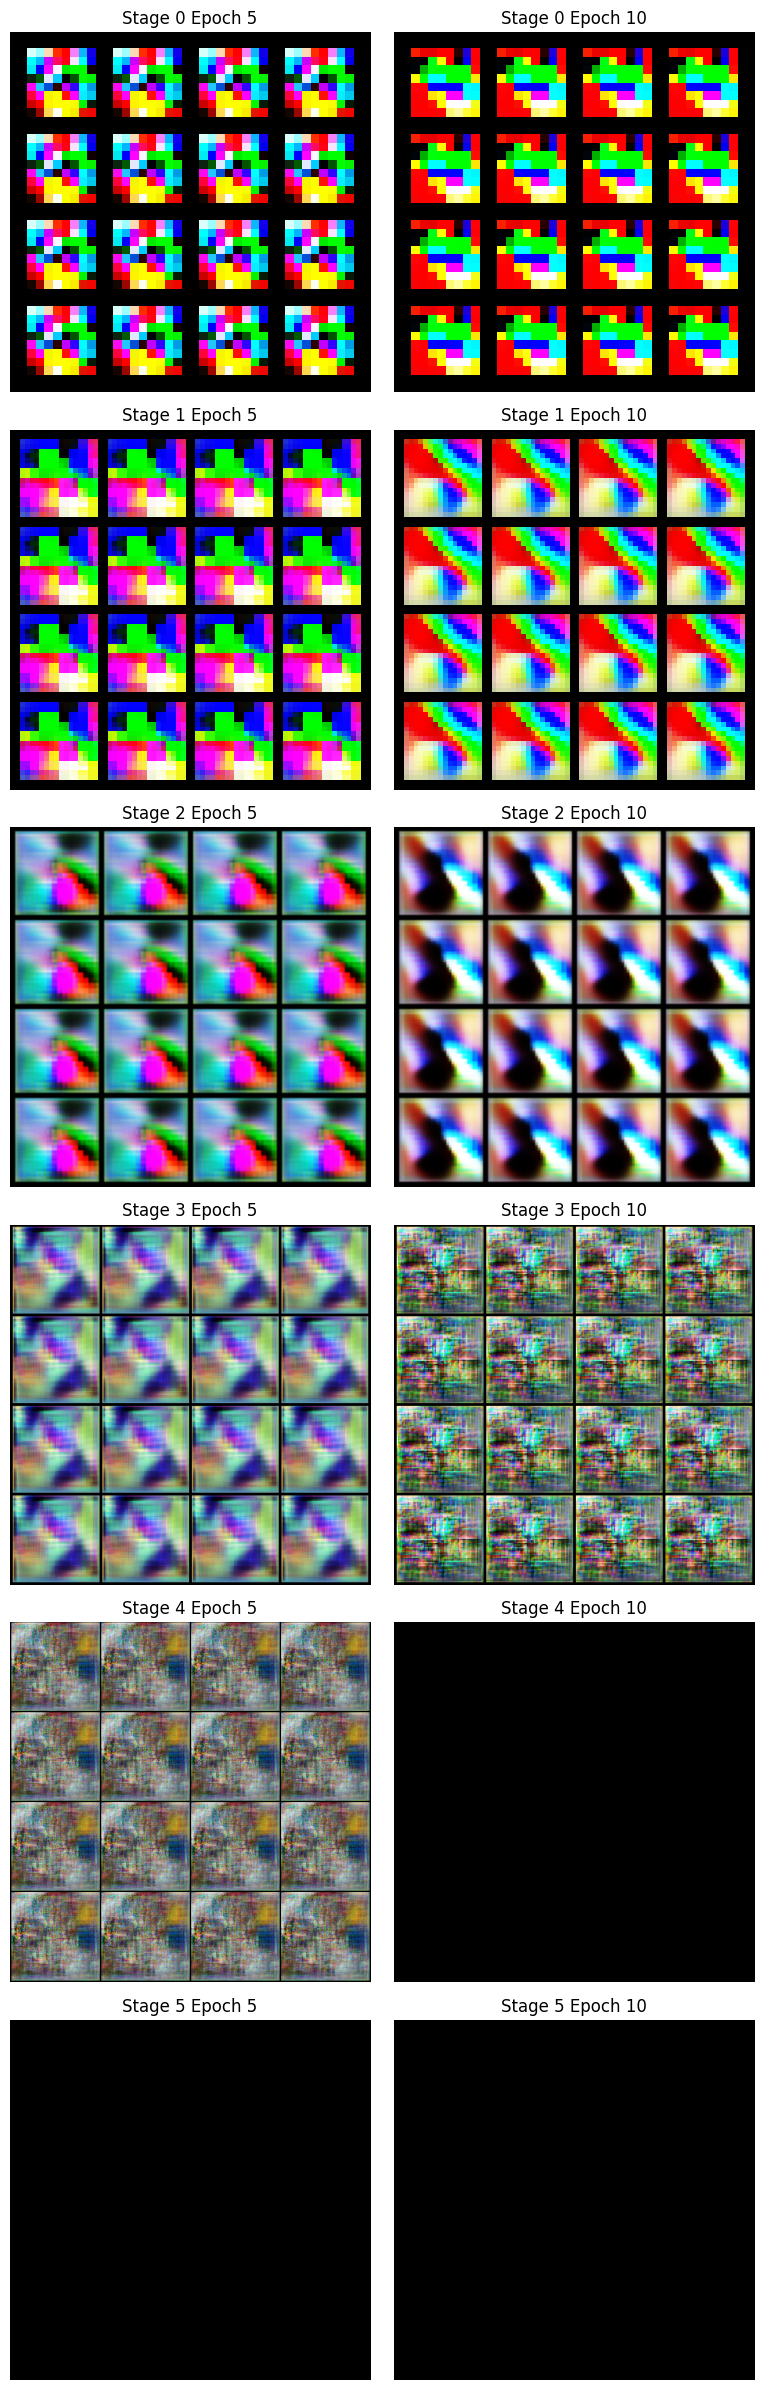

In [51]:
import matplotlib.pyplot as plt
import torchvision
import torch

# Function to show saved samples from each stage
def show_stage_samples(stages, epochs=[5, 10]):
    fig, axes = plt.subplots(len(stages), len(epochs), figsize=(len(epochs)*4, len(stages)*4))

    for i, stage in enumerate(stages):
        for j, epoch in enumerate(epochs):
            img_path = f"samples_stage{stage}_epoch{epoch}.png"
            img = plt.imread(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            axes[i, j].set_title(f"Stage {stage} Epoch {epoch}")

    plt.tight_layout()
    plt.show()

# Example usage: show samples from stages 0–5 at epochs 5 and 10
show_stage_samples(stages=[0,1,2,3,4,5], epochs=[5,10])


# Recap: Why Stage 5 Goes Black
What You’re Seeing
Stage 0–4: Images evolve from noisy blobs into structured patterns.

Stage 5 (128×128): Output collapses to black, meaning the generator is no longer producing meaningful signals.

Why This Happens
Training instability: Higher resolutions are harder to stabilize; the generator can collapse.

Constant input only: Your generator starts from a fixed constant tensor, not injected noise at each block. This limits diversity and can cause collapse at high resolutions.

Learning rate mismatch: At higher resolutions, the discriminator often overwhelms the generator.

Too few epochs per stage: 10 epochs per stage is short; the model hasn’t had time to stabilize before moving up.

What It Means
The GAN is learning at lower resolutions but failing to maintain stability at 128×128.

FID score (72.74) reflects this: decent but not yet realistic.

Visual inspection confirms collapse at the final stage.